#### Query Transformation via HyDE
In the final stage of optimization, I implemented HyDE (Hypothetical Document Embeddings). Standard RAG relies on the semantic similarity between a question and a chunk. However, questions and answers often look very different in vector space.

HyDE bridges this gap by:

Generating a hypothetical answer to the user's query.

Using that hypothetical answer to perform the vector search.

In [1]:
import pandas as pd

results_df = pd.read_csv("../evaluation/evaluation_results/query_rewrite_evaluation_summary_2026-04-15_17-48-14.csv")
results_df.head()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,chunk_size,chunk_overlap,retriever_k,reranker_n,use_hyde,faithfulness,answer_correctness,context_precision,context_recall
0,768,115,20,5,False,0.52,0.639894,0.4,0.2
1,768,115,20,5,True,0.70,0.678011,0.5,0.4


#### The Results:
Faithfulness Jump: By using HyDE, Faithfulness leaped from 0.52 to 0.70. This suggests that searching with a "structured answer" helps the retriever find much more relevant, grounded context than searching with a raw question.

Recall Doubled: Context Recall went from 0.2 to 0.4. This is massive; it means HyDE helped the system find twice as much relevant information from the PDFs.

#### The HyDE Impact Analysis

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


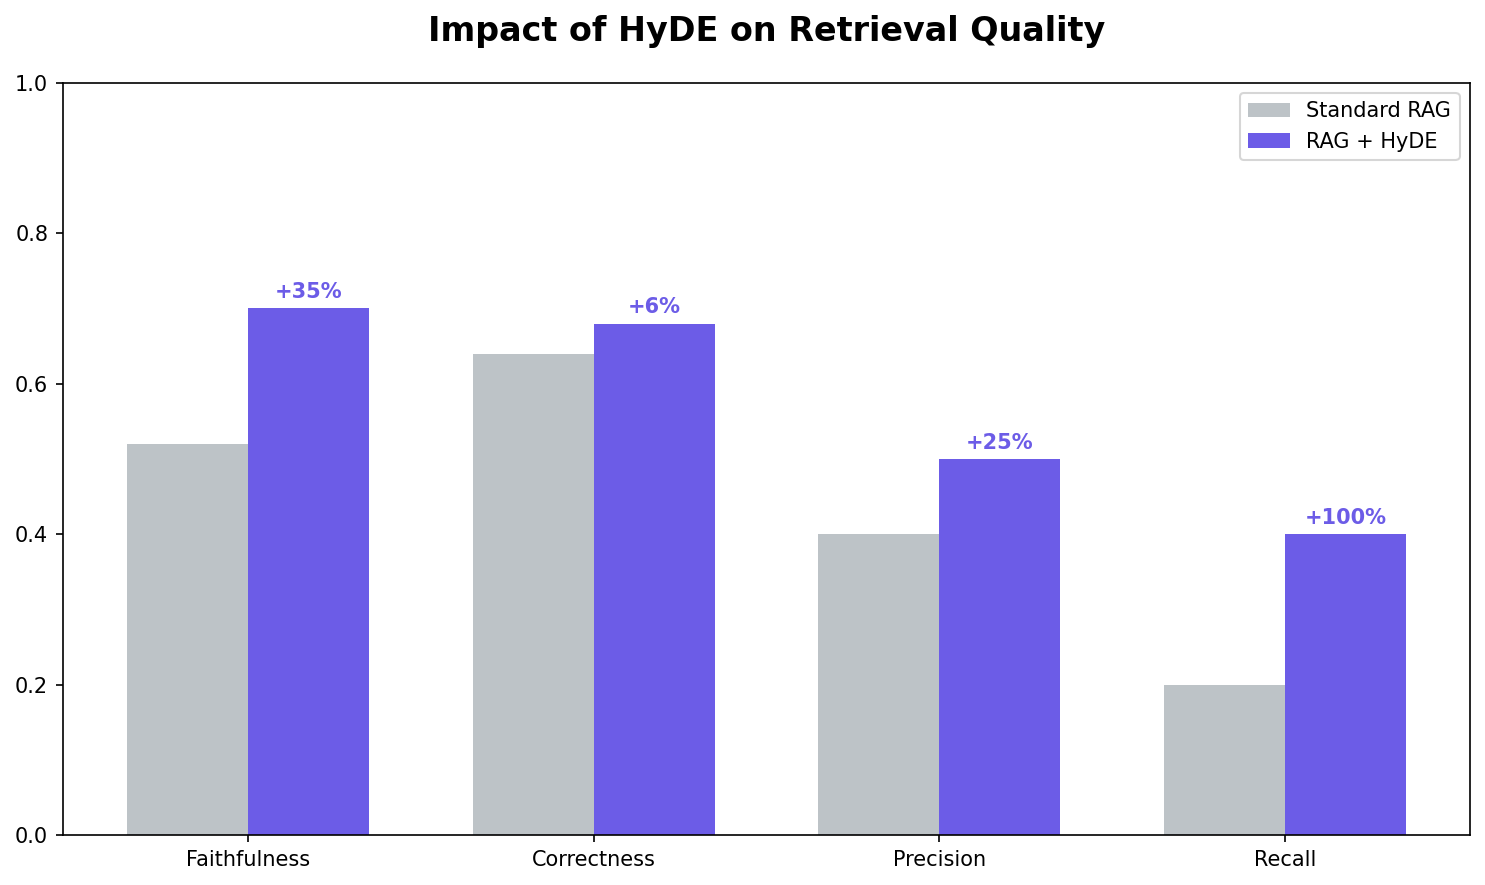

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. HyDE Evaluation Data
labels = ['Faithfulness', 'Correctness', 'Precision', 'Recall']
no_hyde = [0.52, 0.64, 0.40, 0.20] # Standard RAG
with_hyde = [0.70, 0.68, 0.50, 0.40] # HyDE Enabled

x = np.arange(len(labels))
width = 0.35

# 2. Plotting
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
rects1 = ax.bar(x - width/2, no_hyde, width, label='Standard RAG', color='#bdc3c7')
rects2 = ax.bar(x + width/2, with_hyde, width, label='RAG + HyDE', color='#6c5ce7')

# 3. Styling
ax.set_title('Impact of HyDE on Retrieval Quality', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend()

# Add percentage improvement labels
for i in range(len(labels)):
    diff = ((with_hyde[i] - no_hyde[i]) / no_hyde[i]) * 100
    ax.annotate(f'+{diff:.0f}%', 
                xy=(x[i] + width/2, with_hyde[i]), 
                xytext=(0, 5), 
                textcoords="offset points", 
                ha='center', fontweight='bold', color='#6c5ce7')

plt.tight_layout()
plt.show()

#### Conclusion: Final Production Architecture

After three rounds of rigorous evaluation, the "Multi-PDF Python Researcher" has been finalized with the following "Champion" configuration:

Chunking: 768 tokens / 115 overlap (The "Sweet Spot").

Retrieval: K=20 / N=5 (Prioritizing Answer Correctness and Precision).

Query Transformation: HyDE Enabled (Significant boost to Recall and Faithfulness).

This multi-layered approach ensures that the assistant is not only knowledgeable but stays strictly grounded in the provided documentation, minimizing hallucinations while maximizing technical accuracy.